# Modelo Base 1 – Regresión Logística

## 1. Importación de librerías

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

## 2. Carga de datos, separación de variables y Train/Test Split

In [16]:
# Dataset limpio generado en cancer_preprocessing.py
df = pd.read_csv('data/processed/Datos_clean.csv')

# Separamos variables predictoras (X) y variable objetivo (y)
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')

Entrenamiento: 546 muestras
Prueba:        137 muestras


## 3. Entrenamiento del modelo

In [17]:
log_reg = LogisticRegression(
    class_weight='balanced',  
    max_iter=1000,           
    random_state=42
)

log_reg.fit(X_train, y_train)
print('Regresión logística: Modelo entrenado exitosamente.')

rf = RandomForestClassifier(
    n_estimators=100,         # Número de árboles en el bosque
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)
print('Random Forest: Modelo entrenado exitosamente .')

Regresión logística: Modelo entrenado exitosamente.
Random Forest: Modelo entrenado exitosamente .


## 4. Predicciones

In [18]:
# ----- REGRESIÓN LOGÍSTICA -----

# Predicciones sobre el conjunto de prueba
y_pred_log_reg = log_reg.predict(X_test)

# Probabilidades para calcular AUC-ROC
y_prob_log_reg = log_reg.predict_proba(X_test)[:, 1]

# ----- RANDOM FOREST -----

# Predicciones sobre el conjunto de prueba
y_pred_rf = rf.predict(X_test)

# Probabilidades para calcular AUC-ROC
y_prob_rf = rf.predict_proba(X_test)[:, 1]

## 5. Métricas de evaluación
#### Regresión logística
Dado el contexto médico del problema, el **Recall** es la métrica más crítica:
un falso negativo (clasificar un tumor maligno como benigno) tiene consecuencias
clínicas graves. Por eso también reportamos AUC-ROC.

#### Random forest
Al igual que en Regresión Logística, usamos `class_weight='balanced'` para
compensar el desbalance entre clases (65% benigno vs 35% maligno).

In [19]:
def evaluar_modelo(nombre, y_test, y_pred, y_prob):
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    auc_roc   = roc_auc_score(y_test, y_prob)

    print(f'  MÉTRICAS – {nombre.upper()}')
    print('='*40)
    print(f'  Accuracy  : {accuracy:.4f}')
    print(f'  Precision : {precision:.4f}')
    print(f'  Recall    : {recall:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  AUC-ROC   : {auc_roc:.4f}')
    print('\nReporte completo:')
    print(classification_report(y_test, y_pred, target_names=['Benigno (0)', 'Maligno (1)']))

evaluar_modelo('Regresión Logística', y_test, y_pred_log_reg, y_prob_log_reg)
evaluar_modelo('Random Forest',       y_test, y_pred_rf,      y_prob_rf)

  MÉTRICAS – REGRESIÓN LOGÍSTICA
  Accuracy  : 0.9635
  Precision : 0.9216
  Recall    : 0.9792
  F1-Score  : 0.9495
  AUC-ROC   : 0.9909

Reporte completo:
              precision    recall  f1-score   support

 Benigno (0)       0.99      0.96      0.97        89
 Maligno (1)       0.92      0.98      0.95        48

    accuracy                           0.96       137
   macro avg       0.95      0.97      0.96       137
weighted avg       0.96      0.96      0.96       137

  MÉTRICAS – RANDOM FOREST
  Accuracy  : 0.9708
  Precision : 0.9231
  Recall    : 1.0000
  F1-Score  : 0.9600
  AUC-ROC   : 0.9853

Reporte completo:
              precision    recall  f1-score   support

 Benigno (0)       1.00      0.96      0.98        89
 Maligno (1)       0.92      1.00      0.96        48

    accuracy                           0.97       137
   macro avg       0.96      0.98      0.97       137
weighted avg       0.97      0.97      0.97       137



## 6. Matriz de confusión

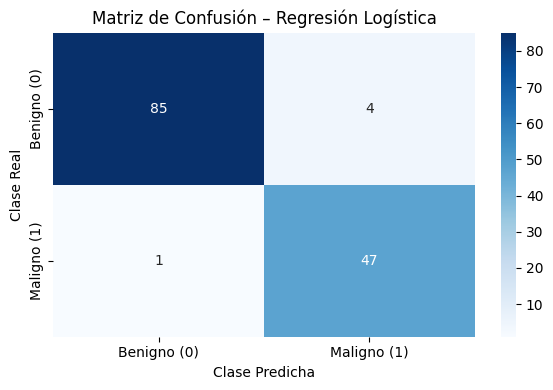

Verdaderos Negativos (benigno correcto): 85
Falsos Positivos (benigno como maligno): 4
Falsos Negativos (maligno como benigno): 1  ← crítico en contexto médico
Verdaderos Positivos (maligno correcto): 47


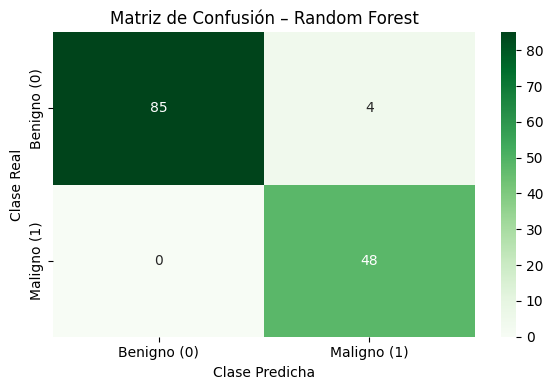

Verdaderos Negativos (benigno correcto): 85
Falsos Positivos (benigno como maligno): 4
Falsos Negativos (maligno como benigno): 0  ← crítico en contexto médico
Verdaderos Positivos (maligno correcto): 48


In [20]:
def plot_confusion_matrix(nombre, y_test, y_pred, cmap='Blues'):
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        xticklabels=['Benigno (0)', 'Maligno (1)'],
        yticklabels=['Benigno (0)', 'Maligno (1)']
    )
    plt.title(f'Matriz de Confusión – {nombre}')
    plt.ylabel('Clase Real')
    plt.xlabel('Clase Predicha')
    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f'Verdaderos Negativos (benigno correcto): {tn}')
    print(f'Falsos Positivos (benigno como maligno): {fp}')
    print(f'Falsos Negativos (maligno como benigno): {fn}  ← crítico en contexto médico')
    print(f'Verdaderos Positivos (maligno correcto): {tp}')

plot_confusion_matrix('Regresión Logística', y_test, y_pred_log_reg, cmap='Blues')
plot_confusion_matrix('Random Forest',       y_test, y_pred_rf,      cmap='Greens')

## 7. Curva ROC

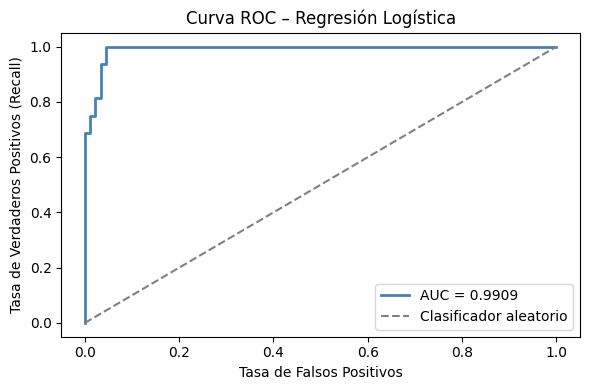

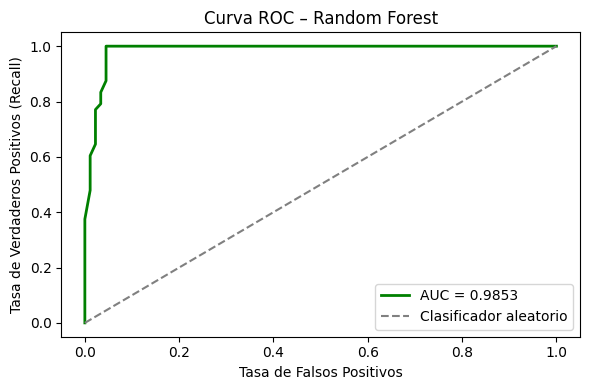

In [21]:
def plot_roc_curve(nombre, y_test, y_prob, color='steelblue'):
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Clasificador aleatorio')
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
    plt.title(f'Curva ROC – {nombre}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

plot_roc_curve('Regresión Logística', y_test, y_prob_log_reg, color='steelblue')
plot_roc_curve('Random Forest',       y_test, y_prob_rf,      color='green')

## 8. Importancia de coeficientes (Regresión logística)

Un coeficiente positivo alto significa que valores altos de esa variable
aumentan la probabilidad de malignidad.

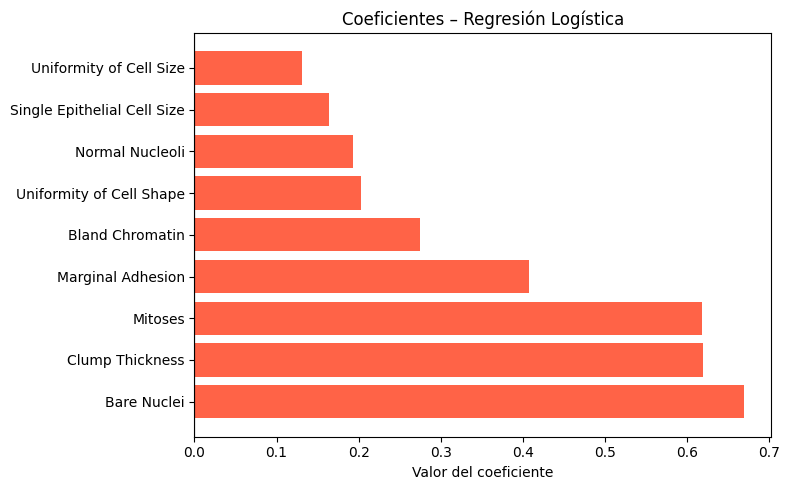

                   Variable  Coeficiente
                Bare Nuclei     0.669024
            Clump Thickness     0.619794
                    Mitoses     0.618472
          Marginal Adhesion     0.407750
            Bland Chromatin     0.274309
   Uniformity of Cell Shape     0.202690
            Normal Nucleoli     0.193161
Single Epithelial Cell Size     0.163866
    Uniformity of Cell Size     0.131284


In [22]:
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': log_reg.coef_[0]
}).sort_values('Coeficiente', ascending=False)

plt.figure(figsize=(8, 5))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coeficiente']]
plt.barh(coef_df['Variable'], coef_df['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes – Regresión Logística')
plt.xlabel('Valor del coeficiente')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

## 9. Importancia de características (Feature Importance)

Una de las ventajas de Random Forest es que calcula de forma nativa
la importancia de cada variable, medida por cuánto reduce la impureza
(Gini) en promedio a lo largo de todos los árboles.
Esto nos permite validar las hipótesis planteadas en el EDA.

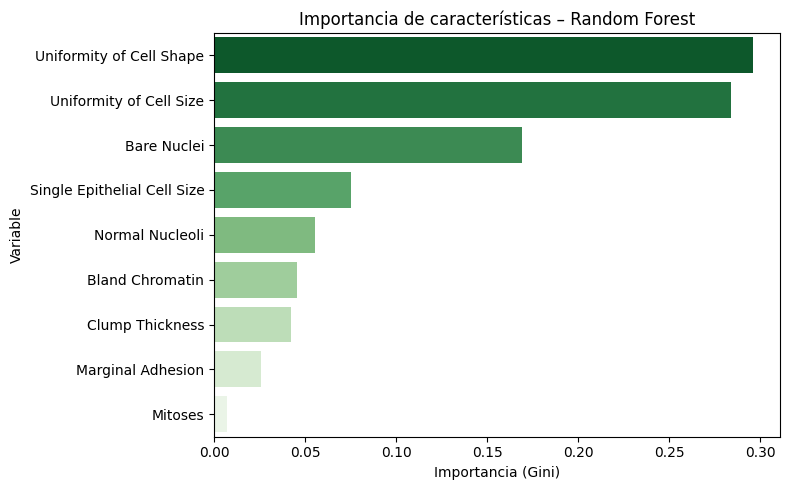

                   Variable  Importancia
   Uniformity of Cell Shape     0.295910
    Uniformity of Cell Size     0.283925
                Bare Nuclei     0.168807
Single Epithelial Cell Size     0.075208
            Normal Nucleoli     0.055559
            Bland Chromatin     0.045371
            Clump Thickness     0.042247
          Marginal Adhesion     0.025791
                    Mitoses     0.007182


In [23]:
importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=importances,
    x='Importancia',
    y='Variable',
    hue='Variable',
    palette='Greens_r',
    legend=False
)
plt.title('Importancia de características – Random Forest')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

print(importances.to_string(index=False))

# XGBoost

In [24]:

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

# Predicciones
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

c:\Users\olivi\OneDrive\Desktop\2026\Semestre 7\mineria de datos\P2-Model-Comparison\a.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [10:49:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# SVM con kernel RBF
Escalar datos

In [25]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

Evaluar ambos modelos 

In [26]:
print("1.----------------------------------")
evaluar_modelo('XGBoost', y_test, y_pred_xgb, y_prob_xgb)
print("2.----------------------------------")
evaluar_modelo('SVM (RBF)', y_test, y_pred_svm, y_prob_svm)


1.----------------------------------
  MÉTRICAS – XGBOOST
  Accuracy  : 0.9708
  Precision : 0.9231
  Recall    : 1.0000
  F1-Score  : 0.9600
  AUC-ROC   : 0.9846

Reporte completo:
              precision    recall  f1-score   support

 Benigno (0)       1.00      0.96      0.98        89
 Maligno (1)       0.92      1.00      0.96        48

    accuracy                           0.97       137
   macro avg       0.96      0.98      0.97       137
weighted avg       0.97      0.97      0.97       137

2.----------------------------------
  MÉTRICAS – SVM (RBF)
  Accuracy  : 0.9635
  Precision : 0.9216
  Recall    : 0.9792
  F1-Score  : 0.9495
  AUC-ROC   : 0.9691

Reporte completo:
              precision    recall  f1-score   support

 Benigno (0)       0.99      0.96      0.97        89
 Maligno (1)       0.92      0.98      0.95        48

    accuracy                           0.96       137
   macro avg       0.95      0.97      0.96       137
weighted avg       0.96      0.96  

curvas ROC y matrices de confusión

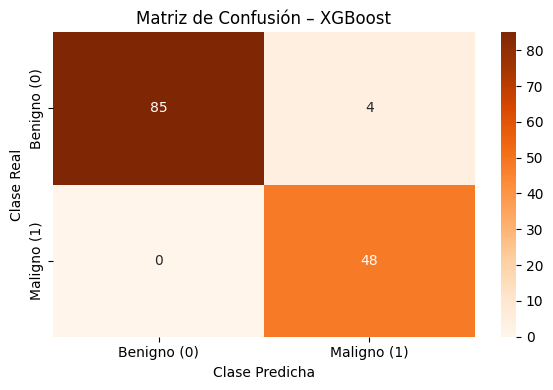

Verdaderos Negativos (benigno correcto): 85
Falsos Positivos (benigno como maligno): 4
Falsos Negativos (maligno como benigno): 0  ← crítico en contexto médico
Verdaderos Positivos (maligno correcto): 48


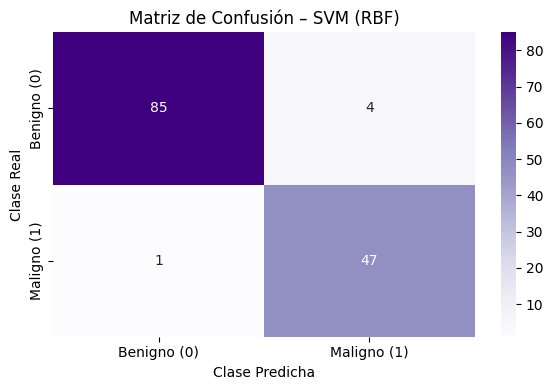

Verdaderos Negativos (benigno correcto): 85
Falsos Positivos (benigno como maligno): 4
Falsos Negativos (maligno como benigno): 1  ← crítico en contexto médico
Verdaderos Positivos (maligno correcto): 47


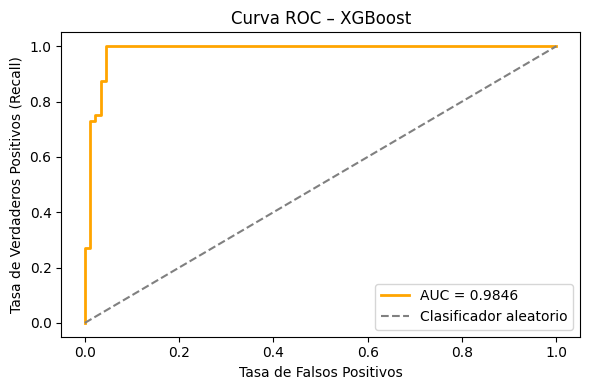

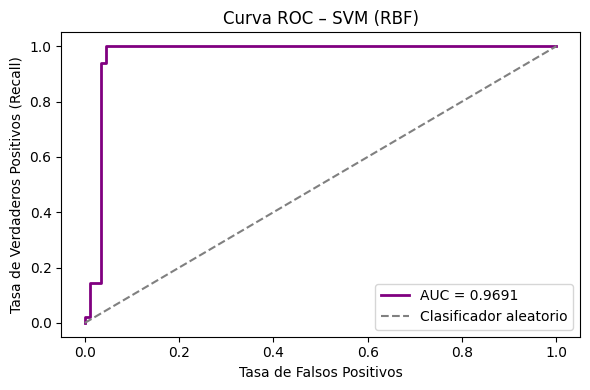

In [27]:
plot_confusion_matrix('XGBoost', y_test, y_pred_xgb, cmap='Oranges')
plot_confusion_matrix('SVM (RBF)', y_test, y_pred_svm, cmap='Purples')

plot_roc_curve('XGBoost', y_test, y_prob_xgb, color='orange')
plot_roc_curve('SVM (RBF)', y_test, y_prob_svm, color='purple')

# Comparación de modelos

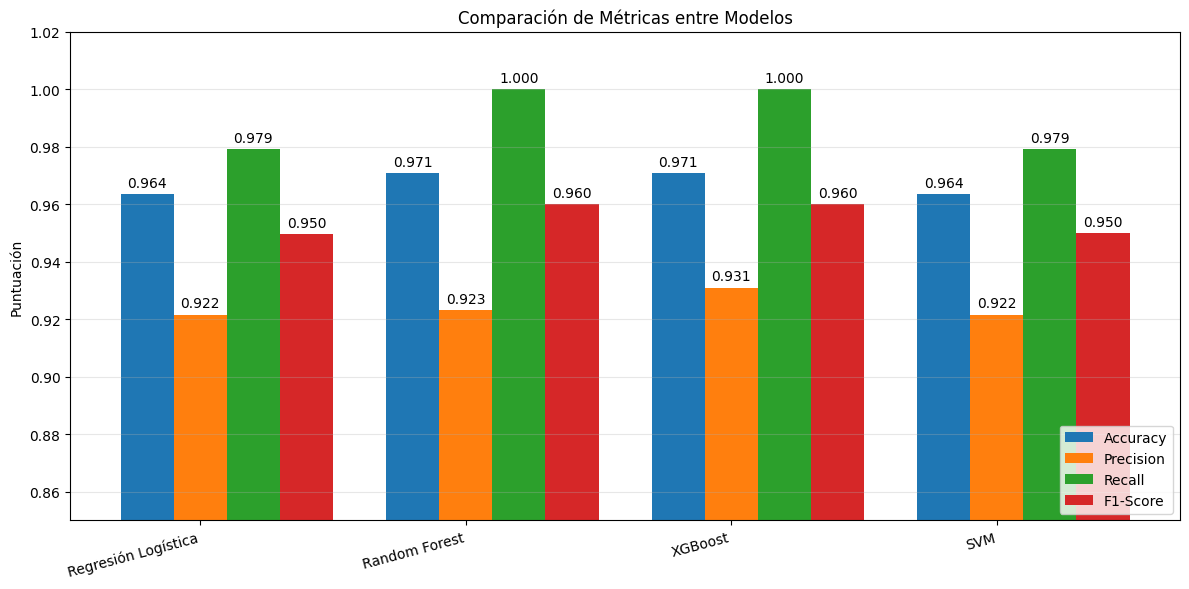

In [28]:

model_names = ['Regresión Logística', 'Random Forest', 'XGBoost', 'SVM']
metrics = {
    'Accuracy': [0.9635, 0.9708, 0.9708, 0.9635],  
    'Precision': [0.9216, 0.9231, 0.931, 0.9216],
    'Recall': [0.9792, 1.0000, 1.0000, 0.9792],
    'F1-Score': [0.9495, 0.9600, 0.96, 0.95]
}


import numpy as np
x = np.arange(len(model_names))
width = 0.2
multiplier = 0

fig, ax = plt.subplots(figsize=(12, 6))

for attribute, measurement in metrics.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3, fmt='%.3f')
    multiplier += 1

ax.set_ylabel('Puntuación')
ax.set_title('Comparación de Métricas entre Modelos')
ax.set_xticks(x + width)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0.85, 1.02)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()